# Observabilité

On interroge dans ce notebook la base SQLite locale (`data/databases/bibops.db`)



In [12]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

DB_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", "databases", "bibops.db")

print(f" Connexion à : {os.path.abspath(DB_PATH)}")

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(
        """
        SELECT
            id,
            ticket_id,
            modele,
            reponse_ia,
            temps_reponse_s,
            note_juge,
            justification_juge
        FROM evaluations
        """,
        conn,
    )

print(f" {len(df)} évaluation(s) chargée(s)")

display(df.head())
print("\nModèles détectés :", df["modele"].unique().tolist())
print("Plage note_juge  :", df["note_juge"].min(), "→", df["note_juge"].max())

 Connexion à : /Users/mohammedakramlrhorfi/PycharmProjects/BibOps-michelin-ensimag-aginux/data/databases/bibops.db
 10 évaluation(s) chargée(s)


,id,ticket_id,modele,reponse_ia,temps_reponse_s,note_juge,justification_juge
0,1,1,llama3.2:1b,Je suis désolé d'apprendre que votre VPN Cisco...,25.41,0,None
1,2,2,llama3.2:1b,"Je suis désolé, mais je ne peux pas vous fourn...",11.00,0,None
2,3,3,llama3.2:1b,Je comprends que vous rencontrez une erreur 40...,18.78,0,None
3,4,1,llama3.2:1b,Désolé à l'égard de votre expérience avec le V...,18.33,0,None
4,5,2,llama3.2:1b,"Je suis désolé, mais je ne peux pas fournir un...",2.57,0,None



Modèles détectés : ['llama3.2:1b', 'phi3:latest', 'test-proxy']
Plage note_juge  : 0 → 8


---

## LLM as a judge — Score moyen par modèle

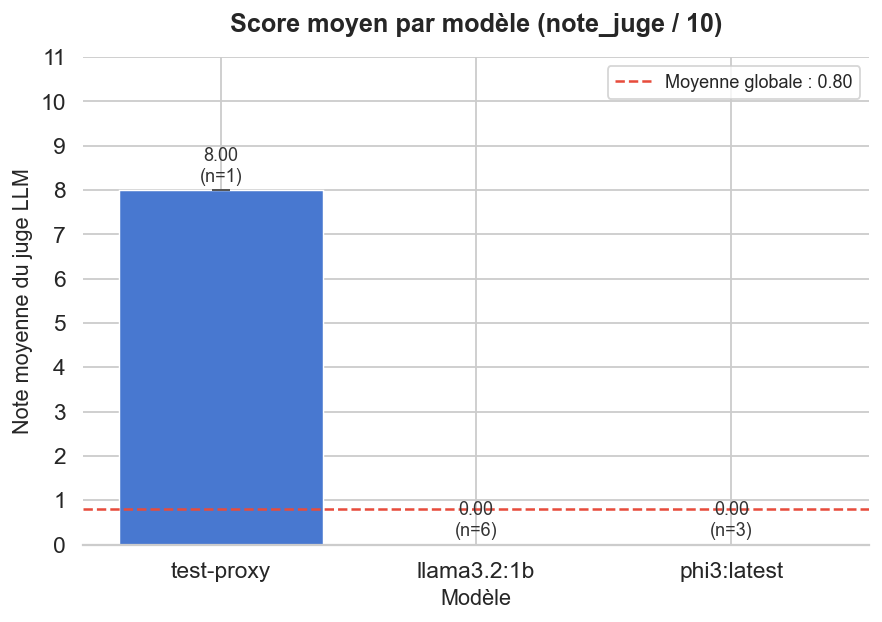

 Sauvegardé → data/benchmark/graphique_1_score_par_modele.png


In [13]:
stats = (
    df.groupby("modele")["note_juge"]
    .agg(moyenne="mean", ecart_type="std", nb="count")
    .reset_index()
    .sort_values("moyenne", ascending=False)
)
stats["ecart_type"] = stats["ecart_type"].fillna(0)
moyenne_globale = df["note_juge"].mean()


# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(7, len(stats) * 1.8), 5))

bars = ax.bar(
    stats["modele"],
    stats["moyenne"],
    yerr=stats["ecart_type"],
    capsize=5,
    color=palette,
    edgecolor="white",
    linewidth=0.8,
    error_kw={"elinewidth": 1.5, "ecolor": "#555"},
)

# Valeur au sommet de chaque barre
for bar, (_, row) in zip(bars, stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + stats["ecart_type"].max() * 0.15 + 0.1,
        f"{row['moyenne']:.2f}\n(n={int(row['nb'])})",
        ha="center", va="bottom", fontsize=10, color="#333",
    )

# Ligne moyenne globale
ax.axhline(moyenne_globale, color="#e74c3c", linestyle="--", linewidth=1.4,
           label=f"Moyenne globale : {moyenne_globale:.2f}")

ax.set_title("Score moyen par modèle (note_juge / 10)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Modèle", fontsize=12)
ax.set_ylabel("Note moyenne du juge LLM", fontsize=12)
ax.set_ylim(0, 11)
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=10)
sns.despine(left=True)

plt.tight_layout()
plt.savefig("../data/benchmark/graphique_1_score_par_modele.png", bbox_inches="tight")
plt.show()
print(" Sauvegardé → data/benchmark/graphique_1_score_par_modele.png")

---

## Latence vs Score


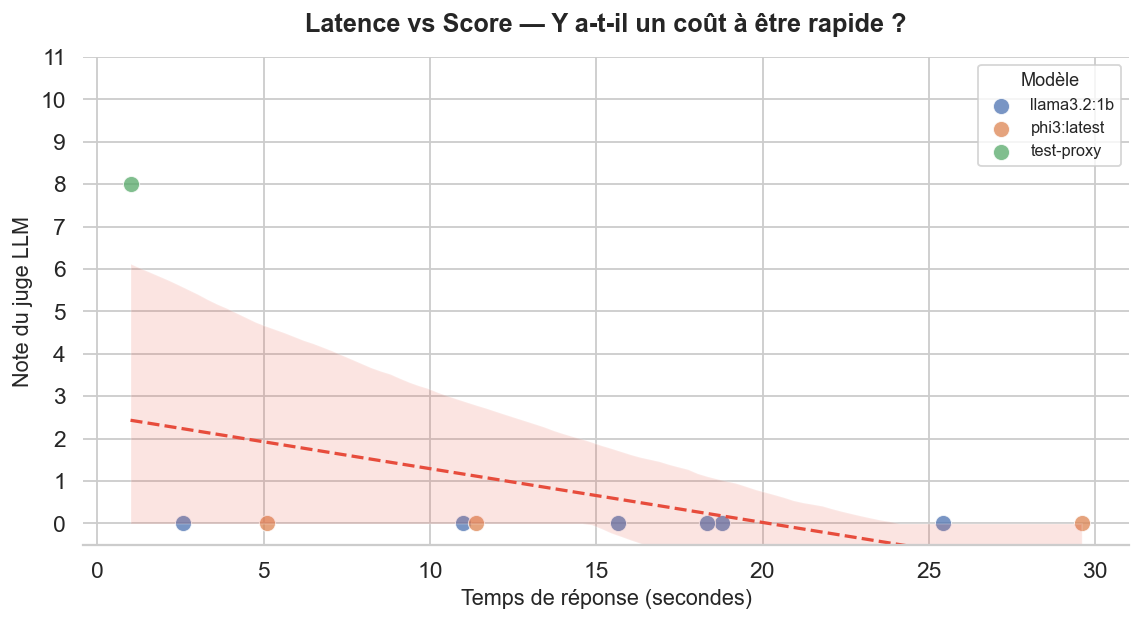

 Sauvegardé → data/benchmark/graphique_2_latence_vs_score.png


In [14]:
# Filtre : on exclut les lignes où le temps est 0 (erreur de mesure)
df_plot = df[df["temps_reponse_s"] > 0].copy()

modeles = df_plot["modele"].unique()
palette_scatter = dict(zip(modeles, sns.color_palette("deep", n_colors=len(modeles))))

fig, ax = plt.subplots(figsize=(9, 5))

# ── Points par modèle ─────────────────────────────────────────────────────
for modele in modeles:
    sub = df_plot[df_plot["modele"] == modele]
    ax.scatter(
        sub["temps_reponse_s"],
        sub["note_juge"],
        label=modele,
        color=palette_scatter[modele],
        s=80, alpha=0.75, edgecolors="white", linewidths=0.6,
    )

# ── Droite de régression globale ──────────────────────────────────────────
if len(df_plot) >= 2:
    sns.regplot(
        data=df_plot,
        x="temps_reponse_s",
        y="note_juge",
        ax=ax,
        scatter=False,
        color="#e74c3c",
        line_kws={"linewidth": 1.8, "linestyle": "--", "label": "Tendance globale"},
        ci=95,
    )

ax.set_title("Latence vs Score — Y a-t-il un coût à être rapide ?",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Temps de réponse (secondes)", fontsize=12)
ax.set_ylabel("Note du juge LLM", fontsize=12)
ax.set_ylim(-0.5, 11)
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

# Légende complète (modèles + tendance)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Modèle", fontsize=9, title_fontsize=10)
sns.despine(left=True)

plt.tight_layout()
plt.savefig("../data/benchmark/graphique_2_latence_vs_score.png", bbox_inches="tight")
plt.show()
print(" Sauvegardé → data/benchmark/graphique_2_latence_vs_score.png")

---

## Réussite des outils (boucle ReAct)

**Définition :** Un appel d'outil est considéré comme un **échec** si la réponse finale de l'agent contient l'un des marqueurs de fallback de `maestro.py` :
- `"Erreur : L'outil"` — l'outil appelé n'existe pas ou a planté
- `"Je n'ai pas pu résoudre le problème"` — la boucle ReAct a atteint sa limite sans trouver de solution

Tout le reste est un **succès**.

Succès : 10 (100.0%)
Échec  : 0 (0.0%)


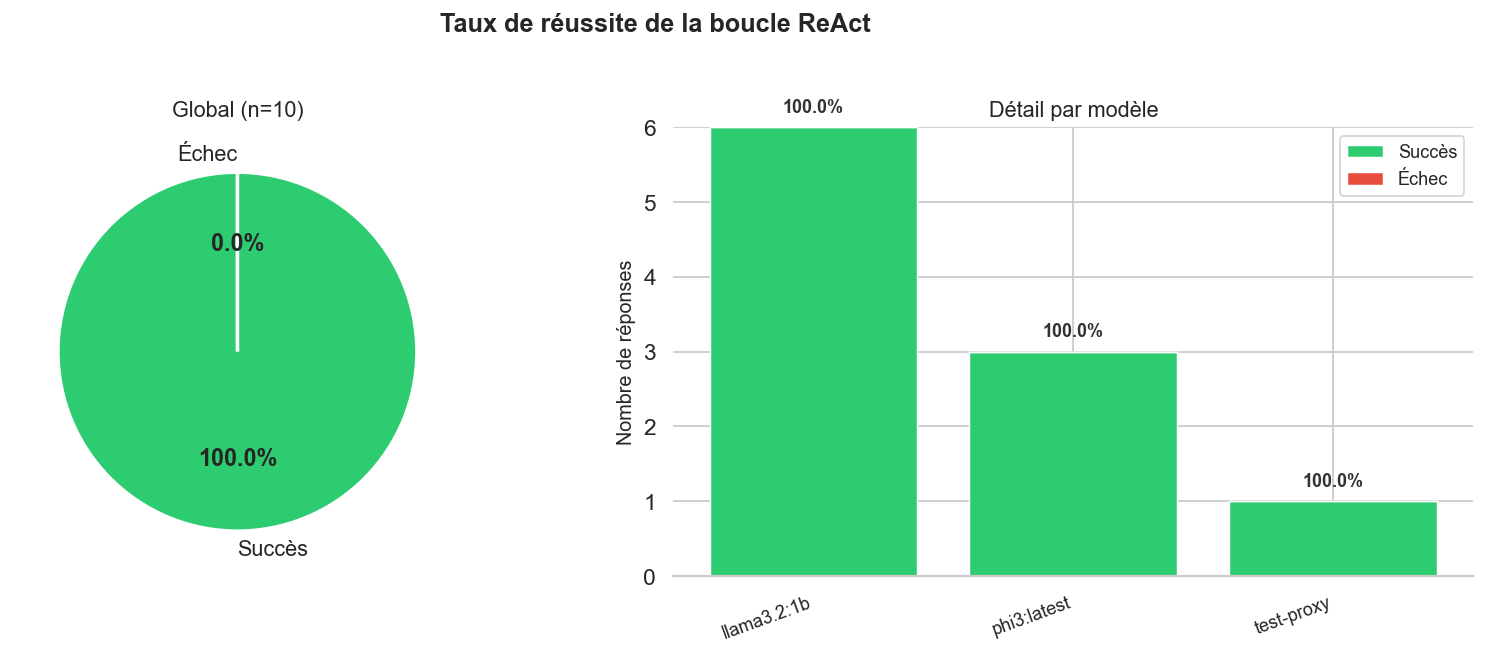

 Sauvegardé → data/benchmark/graphique_3_taux_reussite_outils.png


In [15]:
if df.empty:
    print("Aucune donnée disponible.")
else:
    # ── Détection des échecs ──────────────────────────────────────────────────
    MARQUEURS_ECHEC = [
        "Erreur : L'outil",
        "Je n'ai pas pu résoudre le problème",
    ]

    def est_echec(reponse: str) -> bool:
        if not isinstance(reponse, str):
            return True
        return any(m in reponse for m in MARQUEURS_ECHEC)

    df["statut"] = df["reponse_ia"].apply(lambda r: "Échec" if est_echec(r) else "Succès")

    # ── Comptage global ───────────────────────────────────────────────────────
    counts_global = df["statut"].value_counts()
    total = counts_global.sum()
    taux_succes = counts_global.get("Succès", 0) / total * 100
    taux_echec  = counts_global.get("Échec", 0)  / total * 100

    print(f"Succès : {counts_global.get('Succès', 0)} ({taux_succes:.1f}%)")
    print(f"Échec  : {counts_global.get('Échec',  0)} ({taux_echec:.1f}%)")

    # ── Comptage par modèle ───────────────────────────────────────────────────
    counts_modele = (
        df.groupby(["modele", "statut"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Succès", "Échec"], fill_value=0)
    )
    counts_modele["taux_succes"] = (
        counts_modele["Succès"] / counts_modele.sum(axis=1) * 100
    ).round(1)

    # ── Figure : 2 sous-graphiques ────────────────────────────────────────────
    fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Taux de réussite de la boucle ReAct",
                 fontsize=14, fontweight="bold", y=1.01)

    # — Pie chart global ———————————————————————————————————————————————————————
    couleurs_pie = ["#2ecc71", "#e74c3c"]
    wedges, texts, autotexts = ax_pie.pie(
        counts_global.reindex(["Succès", "Échec"], fill_value=0),
        labels=["Succès", "Échec"],
        autopct="%1.1f%%",
        colors=couleurs_pie,
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 12},
    )
    for at in autotexts:
        at.set_fontsize(13)
        at.set_fontweight("bold")
    ax_pie.set_title(f"Global (n={total})", fontsize=12)

    # — Stacked bar par modèle ─────────────────────────────────────────────────
    x = range(len(counts_modele))
    bar_succes = ax_bar.bar(x, counts_modele["Succès"],
                            color="#2ecc71", label="Succès",
                            edgecolor="white", linewidth=0.8)
    bar_echec  = ax_bar.bar(x, counts_modele["Échec"],
                            bottom=counts_modele["Succès"],
                            color="#e74c3c", label="Échec",
                            edgecolor="white", linewidth=0.8)

    # Taux de succès au sommet de chaque barre
    for i, (idx, row) in enumerate(counts_modele.iterrows()):
        total_modele = row["Succès"] + row["Échec"]
        ax_bar.text(
            i,
            total_modele + 0.15,
            f"{row['taux_succes']}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333",
        )

    ax_bar.set_xticks(list(x))
    ax_bar.set_xticklabels(counts_modele.index, rotation=20, ha="right", fontsize=10)
    ax_bar.set_ylabel("Nombre de réponses", fontsize=11)
    ax_bar.set_title("Détail par modèle", fontsize=12)
    ax_bar.legend(fontsize=10)
    ax_bar.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    sns.despine(ax=ax_bar, left=True)

    plt.tight_layout()
    plt.savefig("../data/benchmark/graphique_3_taux_reussite_outils.png", bbox_inches="tight")
    plt.show()
    print(" Sauvegardé → data/benchmark/graphique_3_taux_reussite_outils.png")